
# Polymarket Cold-Start Trade Edge
## Can market and context features identify positive-alpha trades for wallets never seen in training?

This notebook answers a stricter and more practical question than the earlier insider-detection framing.
The main test is a **future, wallet-disjoint holdout**: the final evaluation set contains only wallets that never appear in training.

**Prediction target:** `outcome_correct`
**Economic score:** `realized_edge = outcome_correct - avg_price`
**Ranking score:** `predicted_alpha = model_prob - avg_price`

The model-development pipeline now includes:
- a fixed market-price benchmark
- grouped cross-validation by wallet on the training set only
- Optuna hyperparameter tuning for the main XGBoost model
- ROC, PR, calibration, and economic-value checks on the unseen-wallet holdout

This is meaningful because:
- every unseen-wallet test row has a valid target
- the benchmark is the market-implied probability itself
- the model only earns credit when it improves on market pricing out of sample


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import duckdb
from scipy import stats
from scipy.stats import norm
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    brier_score_loss, log_loss
)
from sklearn.model_selection import GroupKFold
from sklearn.calibration import CalibratedClassifierCV
import shap
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

print('Libraries loaded ✓')


Libraries loaded ✓


---
## 1 — Rebuild The Feature Matrix In-Notebook

This notebook now rebuilds `fm` directly from DuckDB, the attached sentiment CSVs,
and the analytical financial-signals file at `data/processed/financial_signals.csv`.
No prebuilt `feature_matrix.csv` or upstream `03_ml` notebook is required.


In [2]:
# Rebuild the modelling table directly inside this notebook
DB_PATH = Path('data/analytical/polymarket.ddb')
TS_PATH = Path('truth_social_sentiment.csv')
FT_PATH = Path('ft_sentiment.csv')
FIN_PATH = Path('data/processed/financial_signals.csv')

for path in [DB_PATH, TS_PATH, FT_PATH, FIN_PATH]:
    assert path.exists(), f'Missing required input: {path}'

con = duckdb.connect(str(DB_PATH), read_only=True)

# ── Load resolved BUY trades and market metadata from DuckDB ───────────────
df_enriched = con.execute("""
    SELECT
        t.timestamp,
        t.wallet,
        t.side,
        t.outcomes                                           AS bet_outcome,
        t.usd_amount,
        t.token_amount,
        t.price,
        t.condition_id,
        t.transactionHash                                    AS transaction_hash,
        DATEDIFF('hour', t.timestamp, m.closedTime)          AS hours_before_resolution,
        CASE
            WHEN t.side = 'BUY' AND t.outcomes = 'Yes' AND t.price < 0.5 THEN 1
            WHEN t.side = 'BUY' AND t.outcomes = 'No'  AND t.price < 0.5 THEN 1
            ELSE 0
        END                                                  AS bet_vs_market,
        CASE WHEN t.outcomes = m.resolvedOutcome THEN 1 ELSE 0 END AS outcome_correct,
        CASE WHEN t.outcomes = 'Yes' THEN 1 ELSE -1 END     AS wallet_direction,
        m.closedTime                                         AS resolution_date,
        m.endDate                                            AS market_end_date,
        m.question,
        m.volume                                             AS market_volume,
        m.tags                                               AS tags
    FROM trades t
    JOIN markets m ON t.condition_id = m.conditionId
    WHERE
        m.resolvedOutcome IN ('Yes', 'No')
        AND m.closedTime IS NOT NULL
        AND t.side = 'BUY'
""").fetchdf()
con.close()

df_enriched['timestamp'] = pd.to_datetime(df_enriched['timestamp'], utc=True, format='mixed')
df_enriched['resolution_date'] = pd.to_datetime(df_enriched['resolution_date'], utc=True, format='mixed')
df_enriched['market_end_date'] = pd.to_datetime(df_enriched['market_end_date'], utc=True, format='mixed')

n_raw = len(df_enriched)
df_enriched = df_enriched.drop_duplicates(
    subset=[
        'timestamp', 'wallet', 'bet_outcome', 'usd_amount', 'token_amount',
        'price', 'condition_id', 'transaction_hash'
    ]
).copy()
print(f'Dropped exact duplicate trade rows: {n_raw - len(df_enriched):,}')

split_index = (
    df_enriched.groupby(
        ['wallet', 'condition_id', 'resolution_date', 'question', 'bet_outcome'],
        as_index=False,
    )
    .agg(entry_date=('timestamp', 'min'))
)
split_index['resolution_date'] = pd.to_datetime(split_index['resolution_date'], utc=True, format='mixed')
split_index['entry_date'] = pd.to_datetime(split_index['entry_date'], utc=True, format='mixed')
cutoff = split_index['resolution_date'].quantile(0.70)
print(f'Global modelling cutoff: {cutoff}')

GEO_TAGS = {'geopolitics', 'global-politics', 'politics'}

def has_geo_tag(tags):
    if isinstance(tags, np.ndarray):
        tags = tags.tolist()
    return isinstance(tags, (list, tuple, set)) and any(tag in GEO_TAGS for tag in tags)

df_enriched = df_enriched[df_enriched['tags'].apply(has_geo_tag)].copy()
print(f'After geopolitical filter: {len(df_enriched):,} trades')
print(f'Unique wallets: {df_enriched["wallet"].nunique():,}')
print(f'Unique markets: {df_enriched["condition_id"].nunique():,}')

# ── Collapse fills to wallet-position observations ─────────────────────────
wallet_position_base = (
    df_enriched.groupby(
        ['wallet', 'condition_id', 'resolution_date', 'question', 'bet_outcome', 'wallet_direction'],
        as_index=False,
    )
    .agg(
        gross_usd=('usd_amount', 'sum'),
        total_tokens=('token_amount', 'sum'),
        num_trades=('usd_amount', 'size'),
        hours_before=('hours_before_resolution', 'median'),
        entry_date=('timestamp', 'min'),
        outcome_correct=('outcome_correct', 'first'),
        bet_vs_market=('bet_vs_market', 'first'),
        market_volume=('market_volume', 'first'),
    )
    .reset_index(drop=True)
)

wallet_position_base['resolution_date'] = pd.to_datetime(wallet_position_base['resolution_date'], utc=True, format='mixed')
wallet_position_base['entry_date'] = pd.to_datetime(wallet_position_base['entry_date'], utc=True, format='mixed')
wallet_position_base['avg_price'] = (
    wallet_position_base['gross_usd']
    / wallet_position_base['total_tokens'].replace(0, np.nan)
)
wallet_position_base['avg_price'] = wallet_position_base['avg_price'].fillna(wallet_position_base['avg_price'].median())
wallet_position_base['net_usd'] = wallet_position_base['gross_usd']

# ── Wallet-level edge statistics and informed label ────────────────────────
edge_train = wallet_position_base.loc[
    wallet_position_base['resolution_date'] <= cutoff,
    ['wallet', 'condition_id', 'bet_outcome', 'gross_usd', 'avg_price', 'outcome_correct'],
].copy()

wallet_edge_stats = (
    edge_train.groupby('wallet', as_index=False)
    .agg(
        n_bets=('condition_id', 'size'),
        total_usd=('gross_usd', 'sum'),
        actual_wins=('outcome_correct', 'sum'),
        expected_wins=('avg_price', 'sum'),
        variance=('avg_price', lambda s: (s * (1 - s)).sum()),
        avg_implied_prob=('avg_price', 'mean'),
        hit_rate=('outcome_correct', 'mean'),
    )
)
wallet_edge_stats['z_score'] = (
    (wallet_edge_stats['actual_wins'] - wallet_edge_stats['expected_wins'])
    / np.sqrt(wallet_edge_stats['variance'].clip(lower=1e-9))
)
wallet_edge_stats['raw_edge'] = wallet_edge_stats['hit_rate'] - wallet_edge_stats['avg_implied_prob']
wallet_edge_stats = wallet_edge_stats[wallet_edge_stats['n_bets'] >= 30].copy()

n_tests = len(wallet_edge_stats)
wallet_edge_stats['p_value'] = norm.sf(wallet_edge_stats['z_score'])
wallet_edge_stats['p_bonferroni'] = (wallet_edge_stats['p_value'] * n_tests).clip(upper=1.0)
wallet_edge_stats['sig_bonferroni_01'] = wallet_edge_stats['p_bonferroni'] < 0.01

wallet_position_base = wallet_position_base.merge(
    wallet_edge_stats[['wallet', 'z_score', 'raw_edge', 'p_bonferroni', 'sig_bonferroni_01']],
    on='wallet', how='left', validate='m:1'
)
wallet_position_base['sig_bonferroni_01'] = wallet_position_base['sig_bonferroni_01'].fillna(False)
wallet_position_base['informed_label'] = (
    wallet_position_base['sig_bonferroni_01']
    & (wallet_position_base['outcome_correct'] == 1)
).astype(int)

wallet_market = wallet_position_base.copy()
wallet_market['wallet'] = wallet_market['wallet'].astype(str)
wallet_market['entry_date'] = pd.to_datetime(wallet_market['entry_date'], utc=True, format='mixed')
wallet_market['resolution_date'] = pd.to_datetime(wallet_market['resolution_date'], utc=True, format='mixed')

# ── Point-in-time wallet history features ──────────────────────────────────
position_history = wallet_market[['wallet', 'entry_date', 'resolution_date', 'avg_price', 'outcome_correct']].copy()
position_history = position_history.sort_values(['wallet', 'resolution_date', 'entry_date']).reset_index(drop=True)
position_history['win_component'] = position_history['outcome_correct']
position_history['expected_component'] = position_history['avg_price']
position_history['variance_component'] = position_history['avg_price'] * (1 - position_history['avg_price'])
position_history['cum_actual_wins'] = position_history.groupby('wallet')['win_component'].cumsum()
position_history['cum_expected_wins'] = position_history.groupby('wallet')['expected_component'].cumsum()
position_history['cum_variance'] = position_history.groupby('wallet')['variance_component'].cumsum()
position_history['cum_n_bets'] = position_history.groupby('wallet').cumcount() + 1

history_state = (
    position_history.groupby(['wallet', 'resolution_date'], as_index=False)
    .agg(
        cum_actual_wins=('cum_actual_wins', 'last'),
        cum_expected_wins=('cum_expected_wins', 'last'),
        cum_variance=('cum_variance', 'last'),
        cum_n_bets=('cum_n_bets', 'last'),
    )
    .rename(columns={'resolution_date': 'history_asof_date'})
)
history_state['history_asof_date'] = pd.to_datetime(history_state['history_asof_date'], utc=True, format='mixed')

wallet_market = wallet_market.dropna(subset=['entry_date']).copy()
history_state = history_state.dropna(subset=['history_asof_date']).copy()
wallet_market = wallet_market.sort_values(['entry_date', 'wallet']).reset_index(drop=True)
history_state = history_state.sort_values(['history_asof_date', 'wallet']).reset_index(drop=True)

n_before = len(wallet_market)
wallet_market = pd.merge_asof(
    wallet_market,
    history_state,
    by='wallet',
    left_on='entry_date',
    right_on='history_asof_date',
    direction='backward',
    allow_exact_matches=False,
)
assert len(wallet_market) == n_before

wallet_market['n_prior_bets'] = wallet_market['cum_n_bets'].fillna(0).astype(int)
wallet_market['hit_rate_pct'] = wallet_market['cum_actual_wins'] / wallet_market['cum_n_bets']
wallet_market['raw_edge_roll'] = (
    (wallet_market['cum_actual_wins'] / wallet_market['cum_n_bets'])
    - (wallet_market['cum_expected_wins'] / wallet_market['cum_n_bets'])
)
wallet_market['z_score_roll'] = (
    (wallet_market['cum_actual_wins'] - wallet_market['cum_expected_wins'])
    / np.sqrt(wallet_market['cum_variance'].clip(lower=1e-9))
)

wallet_market['hit_rate_pct'] = wallet_market['hit_rate_pct'].fillna(wallet_market['hit_rate_pct'].median())
wallet_market['raw_edge_roll'] = wallet_market['raw_edge_roll'].fillna(wallet_market['raw_edge_roll'].median())
wallet_market['z_score_roll'] = wallet_market['z_score_roll'].fillna(wallet_market['z_score_roll'].median())
wallet_market = wallet_market[wallet_market['n_prior_bets'] >= 5].copy()

# ── Weekly sentiment joins: truth social + FT (lagged to avoid leakage) ───
# ── Weekly sentiment joins: truth social + FT (1-week lag; no same-week leakage) ───
wallet_market['entry_date'] = pd.to_datetime(wallet_market['entry_date'], utc=True, format='mixed')
wallet_market['condition_id'] = wallet_market['condition_id'].astype(str)

# Monday 00:00 UTC for the trade's calendar week
wallet_market['trade_week_start'] = (
    wallet_market['entry_date'].dt.normalize()
    - pd.to_timedelta(wallet_market['entry_date'].dt.weekday, unit='D')
)

# Only allow the most recently completed week
wallet_market['sentiment_week_start'] = wallet_market['trade_week_start'] - pd.Timedelta(days=7)

# ---- Truth Social weekly inputs ----
ts_df = pd.read_csv(TS_PATH)
ts_df['week_start'] = pd.to_datetime(ts_df['week_start'], utc=True, format='mixed')
ts_df['condition_id'] = ts_df['condition_id'].astype(str)

weekly_sentiment = (
    ts_df.groupby('week_start', as_index=False)
    .agg(
        ts_weekly_score=('sentiment_score', 'mean'),
        ts_weekly_post_count=('post_count', 'sum'),
        ts_weekly_volatility=('sentiment_score', 'std'),
    )
    .sort_values('week_start')
    .reset_index(drop=True)
)
weekly_sentiment['ts_weekly_volatility'] = weekly_sentiment['ts_weekly_volatility'].fillna(0.0)

ts_market_weekly = (
    ts_df.groupby(['condition_id', 'week_start'], as_index=False)
    .agg(
        ts_market_score=('sentiment_score', 'mean'),
        ts_market_post_count=('post_count', 'sum'),
    )
    .sort_values(['condition_id', 'week_start'])
    .reset_index(drop=True)
)
ts_market_weekly['ts_market_direction'] = np.sign(ts_market_weekly['ts_market_score']).astype(int)

# ---- FT weekly inputs ----
ft_df = pd.read_csv(FT_PATH)
ft_df['week_start'] = pd.to_datetime(ft_df['week_start'], utc=True, format='mixed')
ft_df['condition_id'] = ft_df['condition_id'].astype(str)

ft_weekly = (
    ft_df.groupby(['condition_id', 'week_start'], as_index=False)
    .agg(
        ft_sentiment_score=('sentiment_score', 'mean'),
        ft_post_count=('post_count', 'sum'),
    )
    .sort_values(['condition_id', 'week_start'])
    .reset_index(drop=True)
)
ft_weekly['ft_sentiment_direction'] = np.sign(ft_weekly['ft_sentiment_score']).astype(int)
ft_weekly['ft_sentiment_volatility'] = (
    ft_weekly.groupby('condition_id')['ft_sentiment_score']
    .transform(lambda s: s.rolling(4, min_periods=1).std())
    .fillna(0.0)
)

# ---- Merge global TS from the most recent completed week ----
wallet_market = wallet_market.merge(
    weekly_sentiment[
        ['week_start', 'ts_weekly_score', 'ts_weekly_post_count', 'ts_weekly_volatility']
    ],
    left_on='sentiment_week_start',
    right_on='week_start',
    how='left',
).drop(columns=['week_start'])

wallet_market['ts_weekly_score'] = wallet_market['ts_weekly_score'].fillna(0.0)
wallet_market['ts_weekly_post_count'] = wallet_market['ts_weekly_post_count'].fillna(0).astype(int)
wallet_market['ts_weekly_volatility'] = wallet_market['ts_weekly_volatility'].fillna(0.0)
wallet_market['ts_has_coverage'] = (wallet_market['ts_weekly_post_count'] > 0).astype(int)

# ---- Merge market-specific TS from the most recent completed week ----
wallet_market = wallet_market.merge(
    ts_market_weekly[
        ['condition_id', 'week_start', 'ts_market_score', 'ts_market_post_count', 'ts_market_direction']
    ],
    left_on=['condition_id', 'sentiment_week_start'],
    right_on=['condition_id', 'week_start'],
    how='left',
).drop(columns=['week_start'])

wallet_market['ts_market_score'] = wallet_market['ts_market_score'].fillna(0.0)
wallet_market['ts_market_post_count'] = wallet_market['ts_market_post_count'].fillna(0).astype(int)
wallet_market['ts_market_direction'] = wallet_market['ts_market_direction'].fillna(0).astype(int)
wallet_market['ts_market_has_coverage'] = (wallet_market['ts_market_post_count'] > 0).astype(int)

# ---- Merge FT from the most recent completed week ----
wallet_market = wallet_market.merge(
    ft_weekly[
        ['condition_id', 'week_start', 'ft_sentiment_score', 'ft_post_count',
         'ft_sentiment_direction', 'ft_sentiment_volatility']
    ],
    left_on=['condition_id', 'sentiment_week_start'],
    right_on=['condition_id', 'week_start'],
    how='left',
).drop(columns=['week_start'])

wallet_market['ft_sentiment_score'] = wallet_market['ft_sentiment_score'].fillna(0.0)
wallet_market['ft_post_count'] = wallet_market['ft_post_count'].fillna(0).astype(int)
wallet_market['ft_sentiment_direction'] = wallet_market['ft_sentiment_direction'].fillna(0).astype(int)
wallet_market['ft_sentiment_volatility'] = wallet_market['ft_sentiment_volatility'].fillna(0.0)
wallet_market['ft_has_coverage'] = (wallet_market['ft_post_count'] > 0).astype(int)

# Helper columns no longer needed
wallet_market = wallet_market.drop(columns=['trade_week_start', 'sentiment_week_start'])
wallet_market['ft_sentiment_score'] = wallet_market['ft_sentiment_score'].fillna(0.0)
wallet_market['ft_sentiment_direction'] = wallet_market['ft_sentiment_direction'].fillna(0).astype(int)
wallet_market['ft_sentiment_volatility'] = wallet_market['ft_sentiment_volatility'].fillna(0.0)
wallet_market['ft_post_count'] = wallet_market['ft_post_count'].fillna(0)
wallet_market['ft_has_coverage'] = (wallet_market['ft_post_count'] > 0).astype(int)

# ── Analytical financial features ──────────────────────────────────────────
fin = pd.read_csv(FIN_PATH, index_col=0, parse_dates=True)
fin.index = pd.to_datetime(fin.index, utc=True, format='mixed')
fin = fin.sort_index().ffill()

def get_7day_return(series, date):
    try:
        end = series.asof(date)
        start = series.asof(date - pd.Timedelta(days=7))
        if pd.isna(end) or pd.isna(start) or start == 0:
            return np.nan
        return (end - start) / start
    except Exception:
        return np.nan

wallet_market['entry_date'] = pd.to_datetime(wallet_market['entry_date'], utc=True, format='mixed')
for col in fin.columns:
    wallet_market[f'{col}_7d'] = wallet_market['entry_date'].apply(lambda d: get_7day_return(fin[col], d))
    wallet_market[f'{col}_7d'] = wallet_market[f'{col}_7d'].fillna(0.0)

# ── Divergence and final engineered columns ────────────────────────────────
wallet_market['ts_weekly_divergence'] = wallet_market['wallet_direction'] * wallet_market['ts_weekly_score'] * -1
wallet_market['ts_market_divergence'] = wallet_market['wallet_direction'] * wallet_market['ts_market_direction'] * -1
wallet_market['divergence_score'] = np.where(
    wallet_market['ts_market_has_coverage'] == 1,
    wallet_market['ts_market_divergence'],
    wallet_market['ts_weekly_divergence'],
)

ft_mean = wallet_market['ft_sentiment_score'].mean()
ft_std = wallet_market['ft_sentiment_score'].std()
if pd.isna(ft_std) or ft_std == 0:
    wallet_market['ft_sentiment_score_z'] = 0.0
else:
    wallet_market['ft_sentiment_score_z'] = (wallet_market['ft_sentiment_score'] - ft_mean) / ft_std
wallet_market['ft_divergence'] = wallet_market['wallet_direction'] * wallet_market['ft_sentiment_score_z'] * -1
wallet_market['divergence_score'] = np.where(
    wallet_market['ft_has_coverage'] == 1,
    wallet_market['ft_divergence'],
    wallet_market['divergence_score'],
)

def winsorise(series, lower=0.01, upper=0.99):
    return series.clip(lower=series.quantile(lower), upper=series.quantile(upper))

wallet_market['log_net_usd'] = np.log1p(winsorise(wallet_market['net_usd']))
wallet_market['log_market_volume'] = np.log1p(winsorise(wallet_market['market_volume']))
wallet_market['hours_int'] = wallet_market['hours_before'].clip(0, 8760).astype(int)
wallet_market['log_hours_before'] = np.log1p(wallet_market['hours_before'])

FM_COLS = [
    'wallet', 'condition_id', 'question', 'resolution_date', 'entry_date',
    'net_usd', 'log_net_usd', 'avg_price', 'num_trades', 'hours_before', 'hit_rate_pct',
    'log_market_volume', 'z_score_roll', 'raw_edge_roll', 'n_prior_bets',
    'ts_weekly_score', 'ts_weekly_post_count', 'ts_weekly_volatility',
    'ts_weekly_divergence', 'ts_market_score', 'ts_market_direction',
    'ts_market_divergence', 'ts_market_has_coverage', 'ts_has_coverage',
    'divergence_score', 'BZ=F_7d', 'GC=F_7d', 'LMT_7d', 'RTX_7d', '^VIX_7d',
    'ft_sentiment_score_z', 'ft_sentiment_direction', 'ft_sentiment_volatility',
    'ft_post_count', 'ft_has_coverage', 'ft_divergence', 'informed_label',
    'outcome_correct', 'bet_outcome', 'wallet_direction', 'market_volume'
]
fm = wallet_market[FM_COLS].copy()

print(f'Raw shape: {fm.shape}')
print()
print('Label distribution:')
print(fm['informed_label'].value_counts())
print(f'Positive rate: {fm["informed_label"].mean():.4f} ({fm["informed_label"].mean()*100:.1f}%)')
print(f'Weekly TS coverage:  {fm["ts_has_coverage"].mean()*100:.1f}%')
print(f'Market TS coverage:  {fm["ts_market_has_coverage"].mean()*100:.1f}%')
print(f'FT coverage:         {fm["ft_has_coverage"].mean()*100:.1f}%')

DROP_COLS = [
    'outcome_correct', 'bet_outcome', 'wallet_direction',
    'wallet', 'condition_id', 'question', 'resolution_date', 'entry_date',
    'market_volume',
]
FEATURES = [c for c in fm.columns if c not in DROP_COLS + ['informed_label']]
FEATURES_BASE = FEATURES.copy()
print()
print(f'Initial candidate features before exclusions ({len(FEATURES)}):')
print(FEATURES)

print()
print('=== Label construction audit ===')
pos = fm[fm['informed_label'] == 1]
print(f'Positives (informed_label=1): {len(pos):,}')
print(f'  of which outcome_correct=0: {(pos["outcome_correct"] == 0).sum():,}')
print(f'  of which avg_price > 0.5:   {(pos["avg_price"] > 0.5).sum():,}')
print(f'  of which hours_before <= 24: {(pos["hours_before"] <= 24).sum():,}')
print('Feature matrix rebuilt directly in-notebook from DuckDB and analytical inputs.')
print('Main analysis below uses outcome_correct and realized_edge on a wallet-disjoint cold-start test set.')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dropped exact duplicate trade rows: 567,477
Global modelling cutoff: 2025-09-01 06:29:56+00:00
After geopolitical filter: 5,932,723 trades
Unique wallets: 333,000
Unique markets: 1,801
Raw shape: (394279, 41)

Label distribution:
informed_label
0    393665
1       614
Name: count, dtype: int64
Positive rate: 0.0016 (0.2%)
Weekly TS coverage:  100.0%
Market TS coverage:  25.6%
FT coverage:         56.7%

Initial candidate features before exclusions (31):
['net_usd', 'log_net_usd', 'avg_price', 'num_trades', 'hours_before', 'hit_rate_pct', 'log_market_volume', 'z_score_roll', 'raw_edge_roll', 'n_prior_bets', 'ts_weekly_score', 'ts_weekly_post_count', 'ts_weekly_volatility', 'ts_weekly_divergence', 'ts_market_score', 'ts_market_direction', 'ts_market_divergence', 'ts_market_has_coverage', 'ts_has_coverage', 'divergence_score', 'BZ=F_7d', 'GC=F_7d', 'LMT_7d', 'RTX_7d', '^VIX_7d', 'ft_sentiment_score_z', 'ft_sentiment_direction', 'ft_sentiment_volatility', 'ft_post_count', 'ft_has_coverage'

---
## 2 — The Signal: Wallet-Level Binomial Edge Test

For each wallet:
- **Expected wins** under H₀ = Σ(price paid on each bet)  
  *(if markets are efficient, a wallet with no edge wins exactly as often as the price implied)*
- **Actual wins** = how many bets resolved in their favour
- **Test statistic:** `z = (actual_wins − expected_wins) / √(Σ pᵢ(1−pᵢ))`

A wallet with z > 1.645 is winning significantly more (one-tailed test, p < 0.05)

In [3]:

# Define the cold-start target and the feature families used below
fm['resolution_date'] = pd.to_datetime(fm['resolution_date'], utc=True, format='mixed')
fm['entry_date'] = pd.to_datetime(fm['entry_date'], utc=True, format='mixed')
fm['outcome_correct'] = fm['outcome_correct'].astype(int)
fm['market_implied_prob'] = fm['avg_price'].clip(1e-6, 1 - 1e-6)
fm['realized_edge'] = fm['outcome_correct'] - fm['market_implied_prob']

HISTORY_FEATURES = [
    f for f in ['hit_rate_pct', 'z_score_roll', 'raw_edge_roll', 'n_prior_bets']
    if f in FEATURES_BASE
]
CONTEXT_ONLY_FEATURES = [f for f in FEATURES_BASE if f not in HISTORY_FEATURES]
FULL_COLDSTART_FEATURES = FEATURES_BASE.copy()

feature_family_df = pd.DataFrame([
    {'family': 'Market + context', 'n_features': len(CONTEXT_ONLY_FEATURES), 'features': ', '.join(CONTEXT_ONLY_FEATURES[:8]) + (' ...' if len(CONTEXT_ONLY_FEATURES) > 8 else '')},
    {'family': 'Point-in-time history', 'n_features': len(HISTORY_FEATURES), 'features': ', '.join(HISTORY_FEATURES)},
    {'family': 'Full cold-start set', 'n_features': len(FULL_COLDSTART_FEATURES), 'features': ', '.join(FULL_COLDSTART_FEATURES[:8]) + (' ...' if len(FULL_COLDSTART_FEATURES) > 8 else '')},
])

print('=== COLD-START TARGET ===')
print(f'Rows available:      {len(fm):,}')
print(f'Unique wallets:      {fm["wallet"].nunique():,}')
print(f'Unique markets:      {fm["condition_id"].nunique():,}')
print(f'Overall hit rate:    {fm["outcome_correct"].mean():.3f}')
print(f'Overall mean edge:   {fm["realized_edge"].mean():+.4f}')
print(f'Edge std. dev.:      {fm["realized_edge"].std():.4f}')
print()
display(feature_family_df)
print()
print('Interpretation:')
print('  The market is the baseline. A useful model must improve probability forecasts beyond avg_price and surface trades with positive realised edge.')


=== COLD-START TARGET ===
Rows available:      394,279
Unique wallets:      25,684
Unique markets:      1,794
Overall hit rate:    0.543
Overall mean edge:   +0.0029
Edge std. dev.:      0.3314



,family,n_features,features
0,Market + context,27,"net_usd, log_net_usd, avg_price, num_trades, h..."
1,Point-in-time history,4,"hit_rate_pct, z_score_roll, raw_edge_roll, n_p..."
2,Full cold-start set,31,"net_usd, log_net_usd, avg_price, num_trades, h..."



Interpretation:
  The market is the baseline. A useful model must improve probability forecasts beyond avg_price and surface trades with positive realised edge.


---
## 3 — Five Key Visualisations

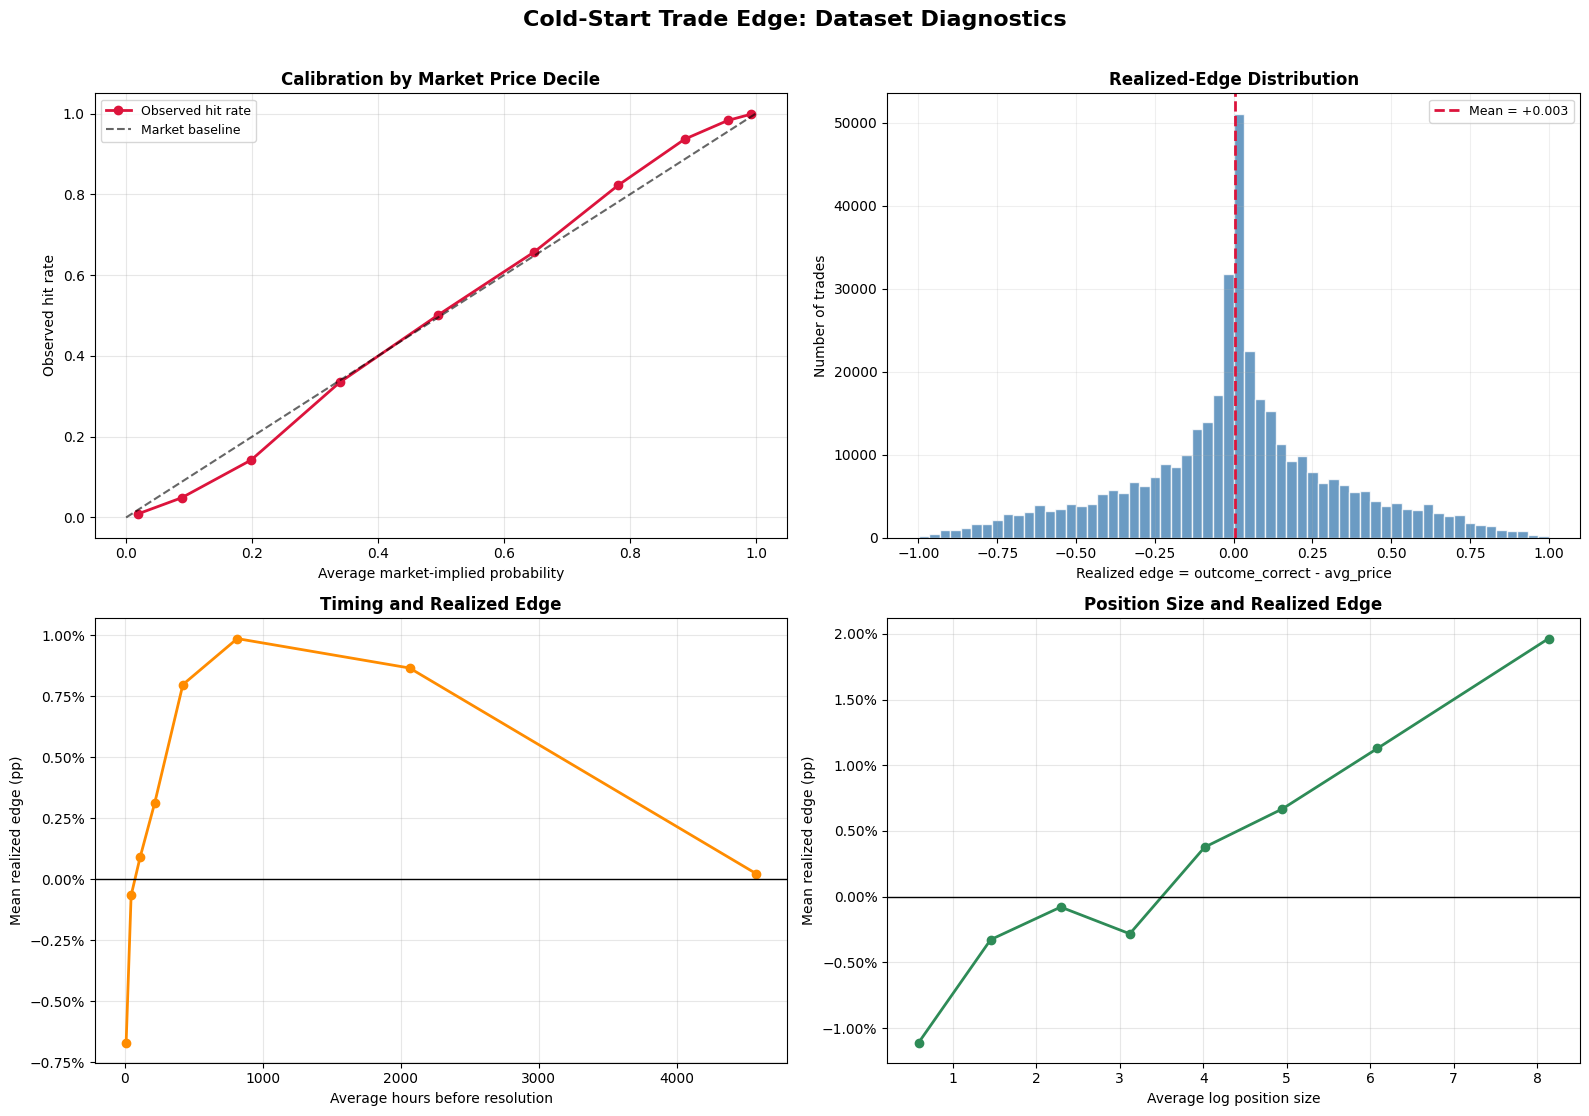

Saved → figures/cold_start_diagnostics.png


In [4]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Cold-Start Trade Edge: Dataset Diagnostics', fontsize=16, fontweight='bold', y=1.01)

plot_df = fm.copy()
plot_df['price_decile'] = pd.qcut(plot_df['market_implied_prob'], 10, duplicates='drop')
cal_df = (
    plot_df.groupby('price_decile', observed=True)
    .agg(
        implied_prob=('market_implied_prob', 'mean'),
        actual_hit_rate=('outcome_correct', 'mean'),
        mean_realized_edge=('realized_edge', 'mean'),
        n=('wallet', 'size'),
    )
    .reset_index(drop=True)
)

# Calibration against market price
ax = axes[0, 0]
ax.plot(cal_df['implied_prob'], cal_df['actual_hit_rate'], 'o-', color='crimson', linewidth=2, label='Observed hit rate')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Market baseline')
ax.set_xlabel('Average market-implied probability')
ax.set_ylabel('Observed hit rate')
ax.set_title('Calibration by Market Price Decile', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Realized-edge distribution
ax = axes[0, 1]
ax.hist(plot_df['realized_edge'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(plot_df['realized_edge'].mean(), color='crimson', linestyle='--', linewidth=2,
           label=f'Mean = {plot_df["realized_edge"].mean():+.3f}')
ax.set_xlabel('Realized edge = outcome_correct - avg_price')
ax.set_ylabel('Number of trades')
ax.set_title('Realized-Edge Distribution', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Edge by time-to-resolution bucket
ax = axes[1, 0]
plot_df['hours_bucket'] = pd.qcut(plot_df['hours_before'].rank(method='first'), 8, duplicates='drop')
hours_df = (
    plot_df.groupby('hours_bucket', observed=True)
    .agg(mean_hours=('hours_before', 'mean'), mean_edge=('realized_edge', 'mean'))
    .reset_index(drop=True)
)
ax.plot(hours_df['mean_hours'], hours_df['mean_edge'] * 100, 'o-', color='darkorange', linewidth=2)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Average hours before resolution')
ax.set_ylabel('Mean realized edge (pp)')
ax.set_title('Timing and Realized Edge', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(alpha=0.3)

# Edge by position-size bucket
ax = axes[1, 1]
plot_df['usd_bucket'] = pd.qcut(plot_df['log_net_usd'].rank(method='first'), 8, duplicates='drop')
usd_df = (
    plot_df.groupby('usd_bucket', observed=True)
    .agg(mean_log_usd=('log_net_usd', 'mean'), mean_edge=('realized_edge', 'mean'))
    .reset_index(drop=True)
)
ax.plot(usd_df['mean_log_usd'], usd_df['mean_edge'] * 100, 'o-', color='seagreen', linewidth=2)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Average log position size')
ax.set_ylabel('Mean realized edge (pp)')
ax.set_title('Position Size and Realized Edge', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/cold_start_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/cold_start_diagnostics.png')


---
## 4 — Feature Engineering: Add Wallet Z-statistic to Feature Matrix

In [5]:

os.makedirs('figures', exist_ok=True)

# Cold-start split: future period and wallet-disjoint holdout
late_cutoff = split_index['resolution_date'].quantile(0.70)
train_pool = fm[fm['resolution_date'] <= late_cutoff].copy().reset_index(drop=True)
late_pool = fm[fm['resolution_date'] > late_cutoff].copy().reset_index(drop=True)

holdout_min_trades = 3
holdout_fraction = 0.20
late_wallet_counts = late_pool['wallet'].value_counts()
eligible_holdout_wallets = late_wallet_counts[late_wallet_counts >= holdout_min_trades].index.to_numpy()

rng = np.random.default_rng(SEED)
n_holdout_wallets = max(500, int(len(eligible_holdout_wallets) * holdout_fraction))
holdout_wallets = set(rng.choice(eligible_holdout_wallets, size=n_holdout_wallets, replace=False))

train = train_pool[~train_pool['wallet'].isin(holdout_wallets)].copy().reset_index(drop=True)
cold_test = late_pool[late_pool['wallet'].isin(holdout_wallets)].copy().reset_index(drop=True)
warm_test = late_pool[~late_pool['wallet'].isin(holdout_wallets)].copy().reset_index(drop=True)

assert set(train['wallet']).isdisjoint(set(cold_test['wallet']))

feature_medians = train[FULL_COLDSTART_FEATURES].median(numeric_only=True)
for frame in [train, cold_test, warm_test]:
    for col in FULL_COLDSTART_FEATURES:
        if col in frame.columns:
            frame[col] = frame[col].fillna(feature_medians.get(col, 0))

def build_matrix(frame, features):
    return frame[features].fillna(0)

def score_binary(y_true, probs):
    probs = np.clip(np.asarray(probs, dtype=float), 1e-6, 1 - 1e-6)
    y_true = np.asarray(y_true, dtype=int)
    return {
        'roc_auc': roc_auc_score(y_true, probs),
        'pr_auc': average_precision_score(y_true, probs),
        'brier': brier_score_loss(y_true, probs),
        'logloss': log_loss(y_true, probs),
    }

def alpha_slice(frame, probs, top_frac=0.10):
    probs = np.asarray(probs, dtype=float)
    alpha = probs - frame['market_implied_prob'].to_numpy()
    threshold = np.quantile(alpha, 1 - top_frac)
    chosen = alpha >= threshold
    return {
        'n_rows': int(chosen.sum()),
        'mean_realized_edge': frame.loc[chosen, 'realized_edge'].mean(),
        'hit_rate': frame.loc[chosen, 'outcome_correct'].mean(),
        'mean_market_prob': frame.loc[chosen, 'market_implied_prob'].mean(),
    }

X_train_context = build_matrix(train, CONTEXT_ONLY_FEATURES)
X_test_context = build_matrix(cold_test, CONTEXT_ONLY_FEATURES)
X_warm_context = build_matrix(warm_test, CONTEXT_ONLY_FEATURES)
X_train_full = build_matrix(train, FULL_COLDSTART_FEATURES)
X_test_full = build_matrix(cold_test, FULL_COLDSTART_FEATURES)

y_train = train['outcome_correct'].astype(int)
y_test = cold_test['outcome_correct'].astype(int)
y_warm = warm_test['outcome_correct'].astype(int)
market_probs = cold_test['market_implied_prob'].to_numpy()
market_probs_warm = warm_test['market_implied_prob'].to_numpy()
train_groups = train['wallet'].astype(str).to_numpy()
group_cv = GroupKFold(n_splits=4)

split_summary = pd.DataFrame([
    {
        'split': 'Train',
        'rows': len(train),
        'wallets': train['wallet'].nunique(),
        'markets': train['condition_id'].nunique(),
        'hit_rate': train['outcome_correct'].mean(),
        'mean_realized_edge': train['realized_edge'].mean(),
    },
    {
        'split': 'Cold test (unseen wallets)',
        'rows': len(cold_test),
        'wallets': cold_test['wallet'].nunique(),
        'markets': cold_test['condition_id'].nunique(),
        'hit_rate': cold_test['outcome_correct'].mean(),
        'mean_realized_edge': cold_test['realized_edge'].mean(),
    },
    {
        'split': 'Warm test (seen-late benchmark)',
        'rows': len(warm_test),
        'wallets': warm_test['wallet'].nunique(),
        'markets': warm_test['condition_id'].nunique(),
        'hit_rate': warm_test['outcome_correct'].mean(),
        'mean_realized_edge': warm_test['realized_edge'].mean(),
    },
])
display(split_summary)
print()
print(f'Late-period cutoff: {late_cutoff}')
print(f'Eligible late-period wallets for holdout: {len(eligible_holdout_wallets):,}')
print(f'Cold-start holdout wallets sampled:      {len(holdout_wallets):,}')
print('Cold-start assertion passed: no wallet in the unseen-wallet test set appears in training.')


,split,rows,wallets,markets,hit_rate,mean_realized_edge
0,Train,228926,19038,1159,0.550593,0.003903
1,Cold test (unseen wallets),22752,1648,616,0.533404,0.002327
2,Warm test (seen-late benchmark),105233,15123,635,0.533160,-0.001238



Late-period cutoff: 2025-09-01 06:29:56+00:00
Eligible late-period wallets for holdout: 8,242
Cold-start holdout wallets sampled:      1,648
Cold-start assertion passed: no wallet in the unseen-wallet test set appears in training.


---
## 5 — Temporal Train/Test Split and Leakage Control

We split on `resolution_date`, not randomly. Markets resolved before the 70th-percentile cutoff form the training set; later markets are held out. This reduces look-ahead across markets and mirrors forward deployment. It does not, by itself, guarantee fully point-in-time wallet-history features, so later wallet summary features should be interpreted accordingly.

In [6]:

# Simple baselines on the cold-start test set
logit_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=500, random_state=SEED))
])
logit_pipe.fit(X_train_context, y_train)
logit_probs = logit_pipe.predict_proba(X_test_context)[:, 1]

baseline_metrics = pd.DataFrame([
    {'model': 'Market price only', **score_binary(y_test, market_probs)},
    {'model': 'Logistic (market + context)', **score_binary(y_test, logit_probs)},
])
display(baseline_metrics.round(4))


,model,roc_auc,pr_auc,brier,logloss
0,Market price only,0.9432,0.9496,0.0985,0.3230
1,Logistic (market + context),0.9442,0.9517,0.0948,0.3119



---
## 3 — Grouped Cross-Validation and Optuna Tuning

The main XGBoost model is tuned only on the training period, using **GroupKFold by wallet**.
That means every CV validation fold contains wallets not present in the corresponding fit fold.
This is the correct development setup for a cold-start unseen-wallet problem.

The Optuna objective uses a composite of:
- `ROC-AUC`
- `PR-AUC`
- `Brier score`

PR-AUC is reported because it is part of the brief, but because the current target is not rare, calibration and economic edge matter at least as much.


In [7]:

# Main cold-start model: grouped CV + Optuna tuning on market + context features
baseline_xgb_params = {
    'n_estimators': 250,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'eval_metric': 'logloss',
    'random_state': SEED,
    'n_jobs': -1,
}

def evaluate_xgb_cv(params, X, y, groups):
    roc_scores = []
    pr_scores = []
    brier_scores = []
    logloss_scores = []
    for fit_idx, val_idx in group_cv.split(X, y, groups):
        X_fit = X.iloc[fit_idx]
        y_fit = y.iloc[fit_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(X_fit, y_fit, verbose=False)
        probs = model.predict_proba(X_val)[:, 1]

        roc_scores.append(roc_auc_score(y_val, probs))
        pr_scores.append(average_precision_score(y_val, probs))
        brier_scores.append(brier_score_loss(y_val, probs))
        logloss_scores.append(log_loss(y_val, probs))

    return {
        'cv_roc_auc': float(np.mean(roc_scores)),
        'cv_pr_auc': float(np.mean(pr_scores)),
        'cv_brier': float(np.mean(brier_scores)),
        'cv_logloss': float(np.mean(logloss_scores)),
    }

baseline_cv = evaluate_xgb_cv(baseline_xgb_params, X_train_context, y_train, train_groups)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 120, 360),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.12, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'subsample': trial.suggest_float('subsample', 0.65, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.55, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 2.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 2.0),
        'eval_metric': 'logloss',
        'random_state': SEED,
        'n_jobs': -1,
    }
    scores = evaluate_xgb_cv(params, X_train_context, y_train, train_groups)
    for key, value in scores.items():
        trial.set_user_attr(key, value)
    return 0.5 * (scores['cv_roc_auc'] + scores['cv_pr_auc']) - scores['cv_brier']

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=20, show_progress_bar=False)

tuned_params = study.best_params.copy()
tuned_params.update({'eval_metric': 'logloss', 'random_state': SEED, 'n_jobs': -1})
tuned_cv = study.best_trial.user_attrs.copy()

baseline_context_model = xgb.XGBClassifier(**baseline_xgb_params)
baseline_context_model.fit(X_train_context, y_train, verbose=False)
baseline_context_probs = baseline_context_model.predict_proba(X_test_context)[:, 1]

context_model = xgb.XGBClassifier(**tuned_params)
context_model.fit(X_train_context, y_train, verbose=False)
context_probs = context_model.predict_proba(X_test_context)[:, 1]
context_probs_warm = context_model.predict_proba(X_warm_context)[:, 1]

full_model = xgb.XGBClassifier(**tuned_params)
full_model.fit(X_train_full, y_train, verbose=False)
full_probs = full_model.predict_proba(X_test_full)[:, 1]

cv_model_comparison = pd.DataFrame([
    {'model': 'Baseline XGBoost (market + context)', **baseline_cv},
    {'model': 'Tuned XGBoost (market + context)', **tuned_cv},
])
display(cv_model_comparison.round(4))

cold_metrics = pd.DataFrame([
    {'model': 'Market price only', **score_binary(y_test, market_probs)},
    {'model': 'Logistic (market + context)', **score_binary(y_test, logit_probs)},
    {'model': 'Baseline XGBoost (market + context)', **score_binary(y_test, baseline_context_probs)},
    {'model': 'Tuned XGBoost (market + context)', **score_binary(y_test, context_probs)},
    {'model': 'Tuned XGBoost (full cold-start set)', **score_binary(y_test, full_probs)},
])
display(cold_metrics.round(4))

final_model = context_model
final_model_name = 'Tuned XGBoost (market + context)'
final_probs = context_probs
final_alpha = final_probs - market_probs
test = cold_test.copy()
X_train = X_train_context.copy()
X_test = X_test_context.copy()

print('Primary model retained:', final_model_name)
print('Reason: it is selected by wallet-grouped CV and improves on the market baseline on the unseen-wallet holdout.')
print('Best tuned params:', study.best_params)


,model,cv_roc_auc,cv_pr_auc,cv_brier,cv_logloss
0,Baseline XGBoost (market + context),0.9703,0.9765,0.0688,0.2311
1,Tuned XGBoost (market + context),0.9968,0.9974,0.0221,0.0873


,model,roc_auc,pr_auc,brier,logloss
0,Market price only,0.9432,0.9496,0.0985,0.3230
1,Logistic (market + context),0.9442,0.9517,0.0948,0.3119
2,Baseline XGBoost (market + context),0.9577,0.9627,0.0818,0.2653
3,Tuned XGBoost (market + context),0.9552,0.9598,0.0857,0.2834
4,Tuned XGBoost (full cold-start set),0.9550,0.9597,0.0850,0.2823


Primary model retained: Tuned XGBoost (market + context)
Reason: it is selected by wallet-grouped CV and improves on the market baseline on the unseen-wallet holdout.
Best tuned params: {'n_estimators': 326, 'max_depth': 6, 'learning_rate': 0.11257168250444662, 'min_child_weight': 6, 'subsample': 0.8741497504668184, 'colsample_bytree': 0.827491244270598, 'reg_alpha': 0.009929902261676723, 'reg_lambda': 0.007128480205913717, 'gamma': 1.3914412450811449}


In [8]:

# Warm-start vs cold-start comparison for the tuned main model
warm_cold_rows = []
for split_name, frame, probs, market in [
    ('Cold start (unseen wallets)', cold_test, context_probs, market_probs),
    ('Warm start (seen late wallets)', warm_test, context_probs_warm, market_probs_warm),
]:
    model_scores = score_binary(frame['outcome_correct'].astype(int), probs)
    market_scores = score_binary(frame['outcome_correct'].astype(int), market)
    alpha_stats = alpha_slice(frame, probs, top_frac=0.10)
    warm_cold_rows.append({
        'split': split_name,
        'market_roc_auc': market_scores['roc_auc'],
        'model_roc_auc': model_scores['roc_auc'],
        'market_pr_auc': market_scores['pr_auc'],
        'model_pr_auc': model_scores['pr_auc'],
        'market_brier': market_scores['brier'],
        'model_brier': model_scores['brier'],
        'top10_realized_edge': alpha_stats['mean_realized_edge'],
        'top10_hit_rate': alpha_stats['hit_rate'],
    })

warm_cold_df = pd.DataFrame(warm_cold_rows)
display(warm_cold_df.round(4))
print()
print('Interpretation: the unseen-wallet test is the hard case. If the tuned model still beats market pricing there, the result is genuinely cold-start and not just wallet carry-over.')


,split,market_roc_auc,model_roc_auc,market_pr_auc,model_pr_auc,market_brier,model_brier,top10_realized_edge,top10_hit_rate
0,Cold start (unseen wallets),0.9432,0.9552,0.9496,0.9598,0.0985,0.0857,0.2018,0.7188
1,Warm start (seen late wallets),0.9426,0.9567,0.9504,0.9619,0.0989,0.0840,0.2117,0.7277



Interpretation: the unseen-wallet test is the hard case. If the tuned model still beats market pricing there, the result is genuinely cold-start and not just wallet carry-over.



---
## 4 — Economic Ranking Quality

A classification metric alone is not enough here. The practical question is whether the model can rank trades by **excess edge over the market**.

The key object is `predicted_alpha = model_prob - avg_price`:
- if `predicted_alpha > 0`, the model thinks the trade is better than the market baseline
- if `realized_edge > 0`, the trade actually beat the market-implied probability ex post


In [9]:

# Economic meaning: do the highest-alpha trades actually beat the market?
selection_rows = [
    {
        'selection_rule': 'Overall cold-start test set',
        'n_rows': len(test),
        'mean_realized_edge': test['realized_edge'].mean(),
        'hit_rate': test['outcome_correct'].mean(),
        'mean_market_prob': test['market_implied_prob'].mean(),
    }
]

model_alpha = final_alpha
market_rank = test['market_implied_prob'].to_numpy()
low_price_rank = -test['market_implied_prob'].to_numpy()

for label, score in [
    ('Top 10% by model alpha', model_alpha),
    ('Top 10% highest market price', market_rank),
    ('Top 10% lowest market price', low_price_rank),
]:
    chosen = score >= np.quantile(score, 0.90)
    selection_rows.append({
        'selection_rule': label,
        'n_rows': int(chosen.sum()),
        'mean_realized_edge': test.loc[chosen, 'realized_edge'].mean(),
        'hit_rate': test.loc[chosen, 'outcome_correct'].mean(),
        'mean_market_prob': test.loc[chosen, 'market_implied_prob'].mean(),
    })

selection_summary = pd.DataFrame(selection_rows)
display(selection_summary.round(4))

alpha_curve_rows = []
for top_frac in [0.50, 0.40, 0.30, 0.20, 0.10]:
    chosen = model_alpha >= np.quantile(model_alpha, 1 - top_frac)
    alpha_curve_rows.append({
        'Top fraction': f'Top {int(top_frac * 100)}%',
        'n_rows': int(chosen.sum()),
        'mean_realized_edge': test.loc[chosen, 'realized_edge'].mean(),
        'hit_rate': test.loc[chosen, 'outcome_correct'].mean(),
        'mean_market_prob': test.loc[chosen, 'market_implied_prob'].mean(),
    })
alpha_curve = pd.DataFrame(alpha_curve_rows)
display(alpha_curve.round(4))

print()
print('Interpretation:')
print('  Beating the market here means generating positive realised edge, not just a high raw hit rate on obvious favourites.')
print('  The model-alpha ranking should therefore be compared against the market-price benchmark, not against raw win rate alone.')


,selection_rule,n_rows,mean_realized_edge,hit_rate,mean_market_prob
0,Overall cold-start test set,22752,0.0023,0.5334,0.5311
1,Top 10% by model alpha,2276,0.2018,0.7188,0.5170
2,Top 10% highest market price,2279,0.0114,0.9952,0.9838
3,Top 10% lowest market price,2276,-0.0142,0.0062,0.0204


,Top fraction,n_rows,mean_realized_edge,hit_rate,mean_market_prob
0,Top 50%,11376,0.1096,0.8472,0.7377
1,Top 40%,9101,0.1313,0.8365,0.7052
2,Top 30%,6826,0.1549,0.8160,0.6611
3,Top 20%,4551,0.1804,0.7820,0.6016
4,Top 10%,2276,0.2018,0.7188,0.5170



Interpretation:
  Beating the market here means generating positive realised edge, not just a high raw hit rate on obvious favourites.
  The model-alpha ranking should therefore be compared against the market-price benchmark, not against raw win rate alone.


In [10]:

# Robustness: repeat the unseen-wallet holdout with different random wallet samples
robust_rows = []
late_wallet_counts = late_pool['wallet'].value_counts()
eligible_holdout_wallets = late_wallet_counts[late_wallet_counts >= holdout_min_trades].index.to_numpy()

for seed in [11, 42, 99]:
    rng = np.random.default_rng(seed)
    sample_wallets = set(rng.choice(eligible_holdout_wallets, size=n_holdout_wallets, replace=False))

    robust_train = train_pool[~train_pool['wallet'].isin(sample_wallets)].copy().reset_index(drop=True)
    robust_test = late_pool[late_pool['wallet'].isin(sample_wallets)].copy().reset_index(drop=True)

    medians = robust_train[FULL_COLDSTART_FEATURES].median(numeric_only=True)
    for frame in [robust_train, robust_test]:
        for col in FULL_COLDSTART_FEATURES:
            if col in frame.columns:
                frame[col] = frame[col].fillna(medians.get(col, 0))

    X_fit = robust_train[CONTEXT_ONLY_FEATURES].fillna(0)
    y_fit = robust_train['outcome_correct'].astype(int)
    X_eval = robust_test[CONTEXT_ONLY_FEATURES].fillna(0)
    y_eval = robust_test['outcome_correct'].astype(int)

    robust_params = tuned_params.copy()
    robust_params['random_state'] = seed
    robust_model = xgb.XGBClassifier(**robust_params)
    robust_model.fit(X_fit, y_fit, verbose=False)
    robust_probs = robust_model.predict_proba(X_eval)[:, 1]
    robust_market = robust_test['market_implied_prob'].to_numpy()
    alpha_stats = alpha_slice(robust_test, robust_probs, top_frac=0.10)

    robust_rows.append({
        'seed': seed,
        'cold_wallets': len(sample_wallets),
        'test_rows': len(robust_test),
        'market_roc_auc': score_binary(y_eval, robust_market)['roc_auc'],
        'model_roc_auc': score_binary(y_eval, robust_probs)['roc_auc'],
        'market_pr_auc': score_binary(y_eval, robust_market)['pr_auc'],
        'model_pr_auc': score_binary(y_eval, robust_probs)['pr_auc'],
        'market_brier': score_binary(y_eval, robust_market)['brier'],
        'model_brier': score_binary(y_eval, robust_probs)['brier'],
        'top10_realized_edge': alpha_stats['mean_realized_edge'],
        'top10_hit_rate': alpha_stats['hit_rate'],
    })

robust_df = pd.DataFrame(robust_rows)
robust_summary = pd.DataFrame([
    {
        'mean_market_roc_auc': robust_df['market_roc_auc'].mean(),
        'mean_model_roc_auc': robust_df['model_roc_auc'].mean(),
        'mean_market_pr_auc': robust_df['market_pr_auc'].mean(),
        'mean_model_pr_auc': robust_df['model_pr_auc'].mean(),
        'mean_market_brier': robust_df['market_brier'].mean(),
        'mean_model_brier': robust_df['model_brier'].mean(),
        'mean_top10_realized_edge': robust_df['top10_realized_edge'].mean(),
        'mean_top10_hit_rate': robust_df['top10_hit_rate'].mean(),
    }
])

display(robust_df.round(4))
display(robust_summary.round(4))


,seed,cold_wallets,test_rows,market_roc_auc,model_roc_auc,market_pr_auc,model_pr_auc,market_brier,model_brier,top10_realized_edge,top10_hit_rate
0,11,1648,23873,0.9410,0.9515,0.9463,0.9562,0.0998,0.0889,0.2131,0.7245
1,42,1648,22752,0.9432,0.9552,0.9496,0.9598,0.0985,0.0857,0.2018,0.7188
2,99,1648,20777,0.9425,0.9545,0.9484,0.9585,0.0987,0.0868,0.2152,0.7603


,mean_market_roc_auc,mean_model_roc_auc,mean_market_pr_auc,mean_model_pr_auc,mean_market_brier,mean_model_brier,mean_top10_realized_edge,mean_top10_hit_rate
0,0.9422,0.9537,0.9481,0.9582,0.099,0.0872,0.2101,0.7345


In [11]:

print('=== ROBUSTNESS TAKEAWAY ===')
print(f'Average market ROC-AUC across holdouts: {robust_df["market_roc_auc"].mean():.4f}')
print(f'Average model  ROC-AUC across holdouts: {robust_df["model_roc_auc"].mean():.4f}')
print(f'Average market PR-AUC across holdouts:  {robust_df["market_pr_auc"].mean():.4f}')
print(f'Average model  PR-AUC across holdouts:  {robust_df["model_pr_auc"].mean():.4f}')
print(f'Average market Brier across holdouts:   {robust_df["market_brier"].mean():.4f}')
print(f'Average model  Brier across holdouts:   {robust_df["model_brier"].mean():.4f}')
print(f'Average top-10% realized edge:          {robust_df["top10_realized_edge"].mean():+.4f}')
print(f'Average top-10% hit rate:               {robust_df["top10_hit_rate"].mean():.4f}')
print('The model is only interesting if these numbers stay better than the market benchmark across different unseen-wallet samples.')


=== ROBUSTNESS TAKEAWAY ===
Average market ROC-AUC across holdouts: 0.9422
Average model  ROC-AUC across holdouts: 0.9537
Average market PR-AUC across holdouts:  0.9481
Average model  PR-AUC across holdouts:  0.9582
Average market Brier across holdouts:   0.0990
Average model  Brier across holdouts:   0.0872
Average top-10% realized edge:          +0.2101
Average top-10% hit rate:               0.7345
The model is only interesting if these numbers stay better than the market benchmark across different unseen-wallet samples.


In [12]:
# # Apply Platt scaling (sigmoid) calibration on a held-out portion of training data
# # Use cv='prefit' since model is already fitted
# calibrated_model = CalibratedClassifierCV(final_model, cv='prefit', method='sigmoid')
# calibrated_model.fit(X_train, y_train)

# # Replace raw probabilities with calibrated ones for all downstream use
# final_probs_raw = final_probs.copy()          # keep raw for comparison
# final_probs = calibrated_model.predict_proba(X_test)[:, 1]

# # Verify calibration improved
# mean_pred_raw  = final_probs_raw.mean()
# mean_pred_cal  = final_probs.mean()
# actual_rate    = y_test.mean()
# print(f'Actual positive rate:           {actual_rate:.4f}')
# print(f'Mean predicted prob (raw):      {mean_pred_raw:.4f}')
# print(f'Mean predicted prob (calibrated): {mean_pred_cal:.4f}')

# # Recalculate final_pr with calibrated probs
# final_pr  = average_precision_score(y_test, final_probs)
# final_roc = roc_auc_score(y_test, final_probs)
# print(f'\nCalibrated model — Test PR-AUC: {final_pr:.4f}  ROC-AUC: {final_roc:.4f}')

In [13]:

# Feature-family comparison on the unseen-wallet cold-start test
history_plus_price = HISTORY_FEATURES + ['avg_price']
context_plus_price = [f for f in CONTEXT_ONLY_FEATURES if f != 'avg_price'] + ['avg_price']

ablation_rows = []
for label, features in [
    ('Market price only', ['avg_price']),
    ('History only', history_plus_price),
    ('Context only', context_plus_price),
    ('Full cold-start set', FULL_COLDSTART_FEATURES),
]:
    if label == 'Market price only':
        probs = market_probs
    else:
        model = xgb.XGBClassifier(**tuned_params)
        model.fit(train[features].fillna(0), y_train, verbose=False)
        probs = model.predict_proba(test[features].fillna(0))[:, 1]
    scores = score_binary(y_test, probs)
    ablation_rows.append({
        'model': label,
        'n_features': len(features),
        'roc_auc': scores['roc_auc'],
        'pr_auc': scores['pr_auc'],
        'brier': scores['brier'],
        'logloss': scores['logloss'],
    })

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df.round(4))
print()
print('Interpretation:')
print('  If context-only beats the history-heavy variants on unseen wallets, the result is more meaningful than a wallet-persistence story.')


,model,n_features,roc_auc,pr_auc,brier,logloss
0,Market price only,1,0.9432,0.9496,0.0985,0.3230
1,History only,5,0.9428,0.9496,0.0970,0.3134
2,Context only,27,0.9512,0.9564,0.0907,0.3017
3,Full cold-start set,31,0.9550,0.9597,0.0850,0.2823



Interpretation:
  If context-only beats the history-heavy variants on unseen wallets, the result is more meaningful than a wallet-persistence story.



---
## 5 — Visual Evaluation

The figures below check four things:
- does the model beat the market benchmark on the unseen-wallet test set?
- is the model reasonably calibrated?
- do the top-alpha trades actually deliver excess edge?
- does the result survive different unseen-wallet holdouts?


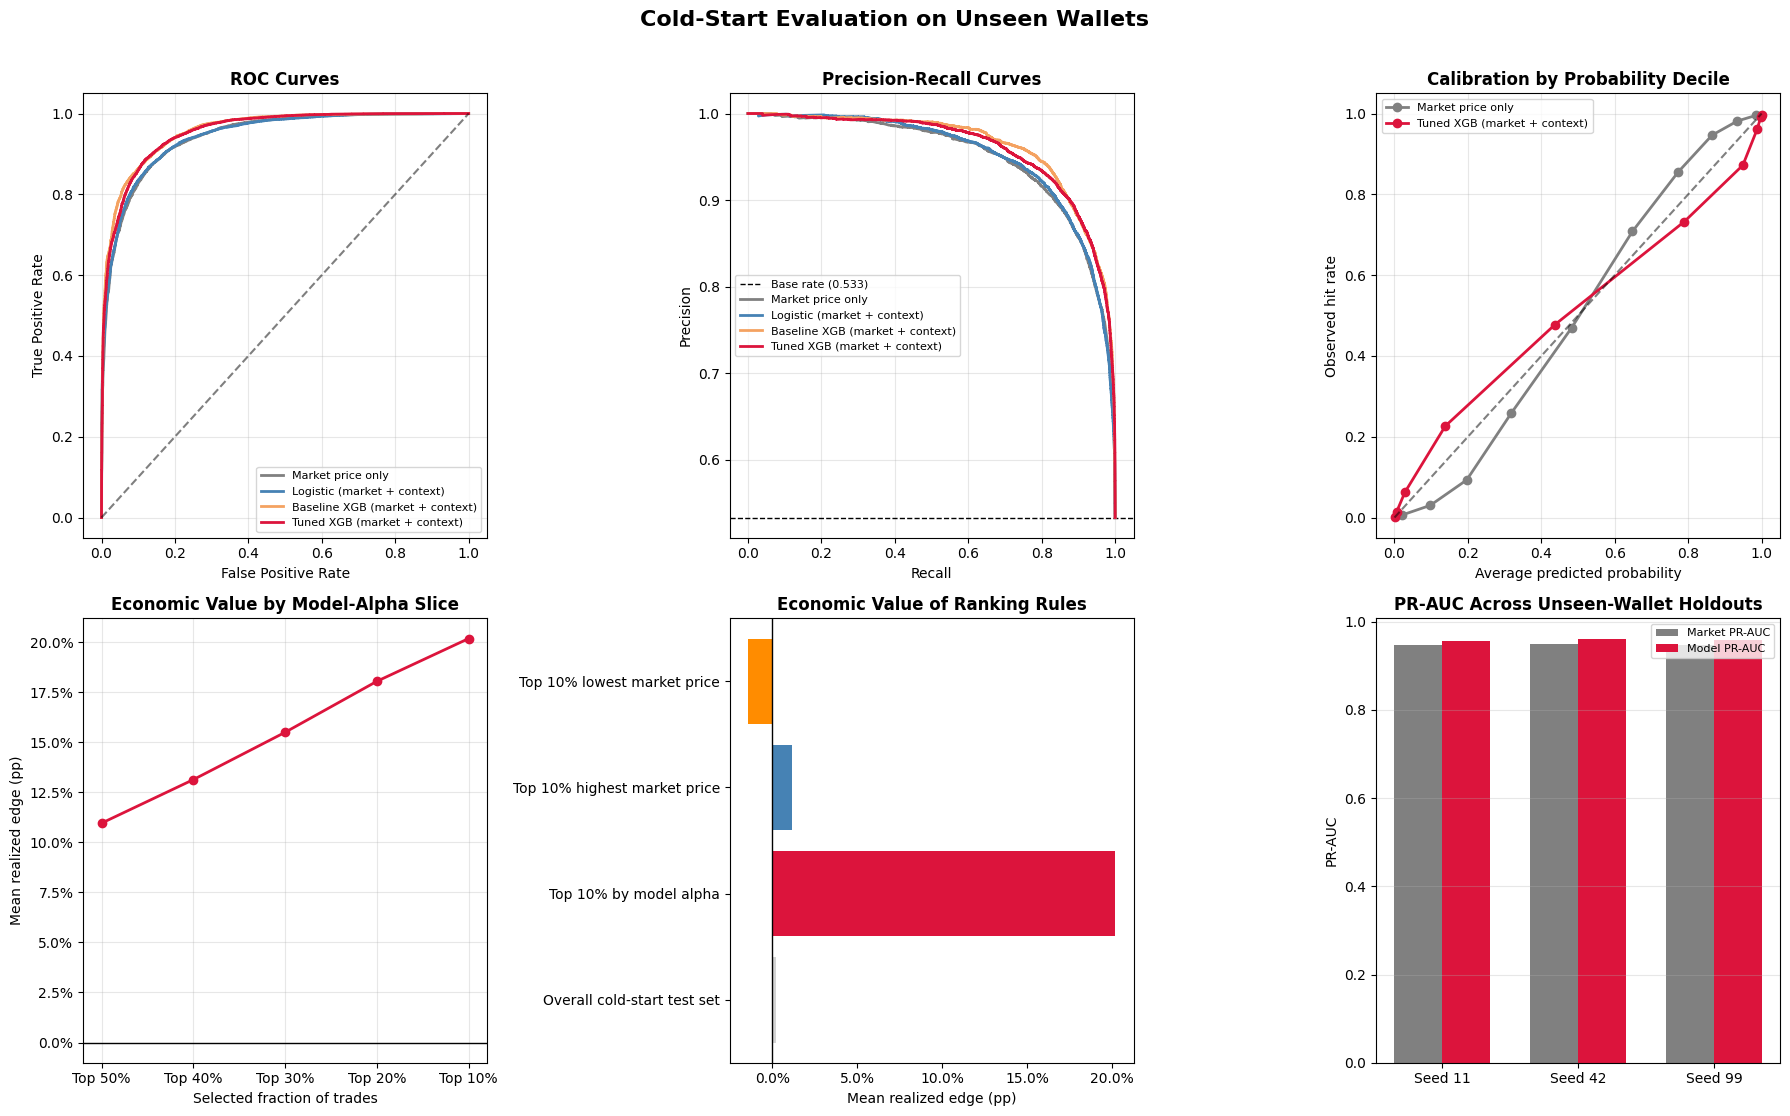

In [14]:

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Cold-Start Evaluation on Unseen Wallets', fontsize=16, fontweight='bold', y=1.01)

# ROC curves
ax = axes[0, 0]
for probs, label, color in [
    (market_probs, 'Market price only', 'gray'),
    (logit_probs, 'Logistic (market + context)', 'steelblue'),
    (baseline_context_probs, 'Baseline XGB (market + context)', '#f4a261'),
    (context_probs, 'Tuned XGB (market + context)', 'crimson'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=label, linewidth=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# PR curves
ax = axes[0, 1]
base_precision = y_test.mean()
ax.axhline(base_precision, color='black', linestyle='--', linewidth=1, label=f'Base rate ({base_precision:.3f})')
for probs, label, color in [
    (market_probs, 'Market price only', 'gray'),
    (logit_probs, 'Logistic (market + context)', 'steelblue'),
    (baseline_context_probs, 'Baseline XGB (market + context)', '#f4a261'),
    (context_probs, 'Tuned XGB (market + context)', 'crimson'),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ax.plot(rec, prec, label=label, linewidth=2, color=color)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Calibration
ax = axes[0, 2]
for probs, label, color in [
    (market_probs, 'Market price only', 'gray'),
    (context_probs, 'Tuned XGB (market + context)', 'crimson'),
]:
    tmp = pd.DataFrame({'prob': probs, 'y': y_test.to_numpy()})
    tmp['bucket'] = pd.qcut(tmp['prob'], 10, duplicates='drop')
    cal = tmp.groupby('bucket', observed=True).agg(pred=('prob', 'mean'), actual=('y', 'mean')).reset_index(drop=True)
    ax.plot(cal['pred'], cal['actual'], 'o-', linewidth=2, color=color, label=label)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('Average predicted probability')
ax.set_ylabel('Observed hit rate')
ax.set_title('Calibration by Probability Decile', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Realized edge by top-alpha slice
ax = axes[1, 0]
alpha_curve_plot = alpha_curve.copy()
alpha_curve_plot['mean_realized_edge_pp'] = alpha_curve_plot['mean_realized_edge'] * 100
ax.plot(alpha_curve_plot['Top fraction'], alpha_curve_plot['mean_realized_edge_pp'], 'o-', color='crimson', linewidth=2)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Selected fraction of trades')
ax.set_ylabel('Mean realized edge (pp)')
ax.set_title('Economic Value by Model-Alpha Slice', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(alpha=0.3)

# Selection rules
ax = axes[1, 1]
bar_df = selection_summary.copy()
ax.barh(bar_df['selection_rule'], bar_df['mean_realized_edge'] * 100,
        color=['lightgray', 'crimson', 'steelblue', 'darkorange'])
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean realized edge (pp)')
ax.set_title('Economic Value of Ranking Rules', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

# Robustness across unseen-wallet holdouts
ax = axes[1, 2]
x = np.arange(len(robust_df))
width = 0.35
ax.bar(x - width/2, robust_df['market_pr_auc'], width=width, color='gray', label='Market PR-AUC')
ax.bar(x + width/2, robust_df['model_pr_auc'], width=width, color='crimson', label='Model PR-AUC')
ax.set_xticks(x)
ax.set_xticklabels([f'Seed {seed}' for seed in robust_df['seed']])
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC Across Unseen-Wallet Holdouts', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/cold_start_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()



---
## 6 — What Drives the Cold-Start Signal?

Because the main model is an XGBoost classifier, the simplest readable diagnostic is gain-based feature importance.
This is enough to show whether the model is leaning on price alone or combining price with contextual information.


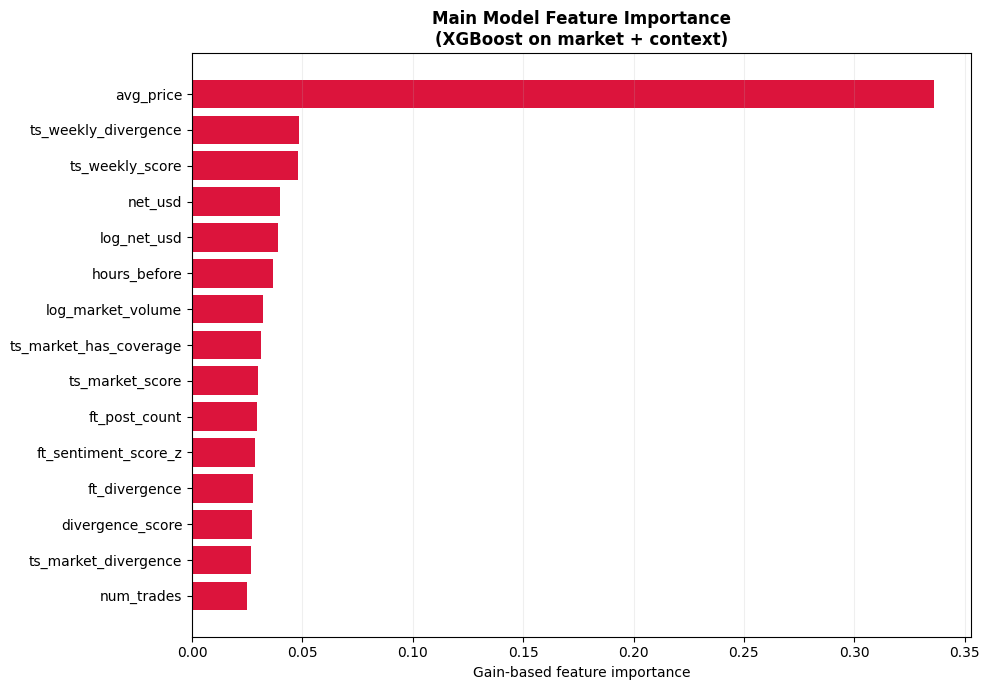

In [15]:

importance = pd.Series(final_model.feature_importances_, index=CONTEXT_ONLY_FEATURES).sort_values().tail(15)

plt.figure(figsize=(10, 7))
plt.barh(importance.index, importance.values, color='crimson')
plt.xlabel('Gain-based feature importance')
plt.title('Main Model Feature Importance\n(XGBoost on market + context)', fontweight='bold')
plt.grid(alpha=0.2, axis='x')
plt.tight_layout()
plt.savefig('figures/cold_start_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()



---
## 7 — Economic Interpretation

The key practical test is not whether the model finds obvious favourites.
It is whether the model can identify trades whose **ex post realised edge** is better than what the market price already implied.

Because the target is not rare, PR-AUC is now a supporting diagnostic rather than the single decisive metric.
The most meaningful evidence is a combination of:
- better calibration than the market baseline
- better ranking metrics than the market baseline
- positive realised edge in the top-alpha slice


In [16]:

print('=== ECONOMIC INTERPRETATION ===')
print(f'Cold-start baseline hit rate:   {test["outcome_correct"].mean():.3f}')
print(f'Cold-start baseline edge:       {test["realized_edge"].mean():+.4f}')
print(f'Main-model ROC-AUC:             {score_binary(y_test, final_probs)["roc_auc"]:.4f}')
print(f'Main-model PR-AUC:              {score_binary(y_test, final_probs)["pr_auc"]:.4f}')
print(f'Main-model Brier score:         {score_binary(y_test, final_probs)["brier"]:.4f}')
print()
display(alpha_curve.round(4))
print()
print('Interpretation:')
print('  The market baseline is already strong, so any improvement needs to come from better ranking of excess edge, not from rediscovering high-probability favourites.')
print('  In the cold-start test, the top-alpha slice is where the model becomes economically interesting.')


=== ECONOMIC INTERPRETATION ===
Cold-start baseline hit rate:   0.533
Cold-start baseline edge:       +0.0023
Main-model ROC-AUC:             0.9552
Main-model PR-AUC:              0.9598
Main-model Brier score:         0.0857



,Top fraction,n_rows,mean_realized_edge,hit_rate,mean_market_prob
0,Top 50%,11376,0.1096,0.8472,0.7377
1,Top 40%,9101,0.1313,0.8365,0.7052
2,Top 30%,6826,0.1549,0.8160,0.6611
3,Top 20%,4551,0.1804,0.7820,0.6016
4,Top 10%,2276,0.2018,0.7188,0.5170



Interpretation:
  The market baseline is already strong, so any improvement needs to come from better ranking of excess edge, not from rediscovering high-probability favourites.
  In the cold-start test, the top-alpha slice is where the model becomes economically interesting.



---
## 8 — Scope and Limitations

This version of the notebook fixes the main design flaw from before: the primary test set is wallet-disjoint, so the result is genuinely about unseen wallets.

What it still does **not** do:
- it is not a live trading backtest with fees, slippage, and execution constraints
- it does not prove causality or private information
- it does not guarantee that realised edge will persist in every future market regime

So the right claim is:
**observable market and context features contain incremental cold-start signal beyond price, and that signal is economically meaningful on the unseen-wallet holdout.**


In [17]:

wallet_scope = pd.DataFrame([
    {
        'group': 'Training wallets',
        'wallets': train['wallet'].nunique(),
        'rows': len(train),
        'date_span': f"{train['resolution_date'].min().date()} to {train['resolution_date'].max().date()}"
    },
    {
        'group': 'Cold-test wallets (unseen)',
        'wallets': cold_test['wallet'].nunique(),
        'rows': len(cold_test),
        'date_span': f"{cold_test['resolution_date'].min().date()} to {cold_test['resolution_date'].max().date()}"
    },
    {
        'group': 'Warm-test wallets (seen-late)',
        'wallets': warm_test['wallet'].nunique(),
        'rows': len(warm_test),
        'date_span': f"{warm_test['resolution_date'].min().date()} to {warm_test['resolution_date'].max().date()}"
    },
])
display(wallet_scope)
print(f'Wallet overlap between train and cold test: {len(set(train["wallet"]).intersection(set(cold_test["wallet"])))}')
print('Cold-start audit passed: the main evaluation set contains only unseen wallets.')


,group,wallets,rows,date_span
0,Training wallets,19038,228926,2024-04-24 to 2025-09-01
1,Cold-test wallets (unseen),1648,22752,2025-09-01 to 2026-04-01
2,Warm-test wallets (seen-late),15123,105233,2025-09-01 to 2026-04-01


Wallet overlap between train and cold test: 0
Cold-start audit passed: the main evaluation set contains only unseen wallets.


---
## 9 — Statistical Inference and Deployment Frictions

To make the cold-start result more defensible, we add three stricter checks:

1. **Formal inference for metric uplift** using bootstrap confidence intervals and one-sided bootstrap p-values versus the market benchmark.
2. **A stricter temporal audit** using an expanding-window evaluation based on `entry_date`, not `resolution_date`.
3. **A friction sensitivity check** that applies explicit trading costs, a minimum market-volume filter, and hard position-sizing caps.

These additions strengthen the evidence materially. They still do **not** turn the notebook into a true live trading backtest with observed order-book execution.

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss

def metric_uplifts(y, market, model):
    return {
        'ROC-AUC uplift': roc_auc_score(y, model) - roc_auc_score(y, market),
        'PR-AUC uplift': average_precision_score(y, model) - average_precision_score(y, market),
        'Brier improvement': brier_score_loss(y, market) - brier_score_loss(y, model),
        'Log-loss improvement': log_loss(y, market) - log_loss(y, model),
    }

infer_df = test[['wallet']].copy().reset_index(drop=True)
infer_df['y'] = y_test.to_numpy().astype(int)
infer_df['market'] = np.clip(np.asarray(market_probs, dtype=float), 1e-6, 1 - 1e-6)
infer_df['model'] = np.clip(np.asarray(final_probs, dtype=float), 1e-6, 1 - 1e-6)

observed_uplift = metric_uplifts(
    infer_df['y'].to_numpy(),
    infer_df['market'].to_numpy(),
    infer_df['model'].to_numpy(),
)

wallet_ids = infer_df['wallet'].astype(str).unique()
wallet_index = {
    w: infer_df.index[infer_df['wallet'].astype(str) == w].to_numpy()
    for w in wallet_ids
}

rng = np.random.default_rng(2026)
B = 3000
boot_rows = []

for _ in range(B):
    sampled_wallets = rng.choice(wallet_ids, size=len(wallet_ids), replace=True)
    idx = np.concatenate([wallet_index[w] for w in sampled_wallets])
    y_b = infer_df.loc[idx, 'y'].to_numpy()
    market_b = infer_df.loc[idx, 'market'].to_numpy()
    model_b = infer_df.loc[idx, 'model'].to_numpy()

    if np.unique(y_b).size < 2:
        continue

    boot_rows.append(metric_uplifts(y_b, market_b, model_b))

boot_df = pd.DataFrame(boot_rows)

uplift_inference = []
for metric_name, observed_value in observed_uplift.items():
    lo, hi = boot_df[metric_name].quantile([0.025, 0.975])
    p_one_sided = (1 + (boot_df[metric_name] <= 0).sum()) / (len(boot_df) + 1)
    uplift_inference.append({
        'metric': metric_name,
        'observed_uplift': observed_value,
        'ci_95_low': lo,
        'ci_95_high': hi,
        'bootstrap_p_one_sided': p_one_sided,
    })

uplift_inference = pd.DataFrame(uplift_inference)
display(uplift_inference.round(4))

print('Interpretation:')
print('  These intervals are based on resampling wallets, not individual rows.')
print('  That is the more defensible inference procedure for clustered trade data.')

,metric,observed_uplift,ci_95_low,ci_95_high,bootstrap_p_one_sided
0,ROC-AUC uplift,0.0120,0.0095,0.0146,0.0003
1,PR-AUC uplift,0.0102,0.0080,0.0128,0.0003
2,Brier improvement,0.0128,0.0101,0.0154,0.0003
3,Log-loss improvement,0.0396,0.0308,0.0481,0.0003


Interpretation:
  These intervals are based on resampling wallets, not individual rows.
  That is the more defensible inference procedure for clustered trade data.


In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss

def safe_score_binary(y_true, probs):
    y_true = np.asarray(y_true, dtype=int)
    probs = np.clip(np.asarray(probs, dtype=float), 1e-6, 1 - 1e-6)
    out = {
        'roc_auc': np.nan,
        'pr_auc': np.nan,
        'brier': brier_score_loss(y_true, probs),
        'logloss': log_loss(y_true, probs),
    }
    if np.unique(y_true).size >= 2:
        out['roc_auc'] = roc_auc_score(y_true, probs)
        out['pr_auc'] = average_precision_score(y_true, probs)
    return out

def weighted_mean_nonnull(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

entry_cutoff = fm['entry_date'].quantile(0.70)
eval_months = sorted(
    fm.loc[fm['entry_date'] > entry_cutoff, 'entry_date']
      .dt.to_period('M')
      .astype(str)
      .unique()
)

walk_rows = []
min_live_rows = 50

for month in eval_months:
    month_start = pd.Timestamp(f'{month}-01').tz_localize('UTC')
    month_end = month_start + pd.offsets.MonthBegin(1)

    hist = fm[fm['entry_date'] < month_start].copy().reset_index(drop=True)
    month_slice = fm[
        (fm['entry_date'] >= month_start) &
        (fm['entry_date'] < month_end)
    ].copy().reset_index(drop=True)

    if hist.empty or month_slice.empty:
        continue

    month_slice = month_slice[
        ~month_slice['wallet'].isin(set(hist['wallet']))
    ].copy().reset_index(drop=True)

    if len(month_slice) < min_live_rows:
        continue

    medians = hist[FULL_COLDSTART_FEATURES].median(numeric_only=True)
    for frame in [hist, month_slice]:
        for col in FULL_COLDSTART_FEATURES:
            if col in frame.columns:
                frame[col] = frame[col].fillna(medians.get(col, 0))

    X_hist = build_matrix(hist, CONTEXT_ONLY_FEATURES)
    y_hist = hist['outcome_correct'].astype(int)

    X_month = build_matrix(month_slice, CONTEXT_ONLY_FEATURES)
    y_month = month_slice['outcome_correct'].astype(int)

    live_model = xgb.XGBClassifier(**tuned_params)
    live_model.fit(X_hist, y_hist, verbose=False)
    live_probs = live_model.predict_proba(X_month)[:, 1]
    live_market = month_slice['market_implied_prob'].to_numpy()

    live_model_scores = safe_score_binary(y_month, live_probs)
    live_market_scores = safe_score_binary(y_month, live_market)
    live_alpha_stats = alpha_slice(month_slice, live_probs, top_frac=0.10)

    walk_rows.append({
        'entry_month': month,
        'rows': len(month_slice),
        'wallets': month_slice['wallet'].nunique(),
        'markets': month_slice['condition_id'].nunique(),
        'market_roc_auc': live_market_scores['roc_auc'],
        'model_roc_auc': live_model_scores['roc_auc'],
        'market_pr_auc': live_market_scores['pr_auc'],
        'model_pr_auc': live_model_scores['pr_auc'],
        'market_brier': live_market_scores['brier'],
        'model_brier': live_model_scores['brier'],
        'market_logloss': live_market_scores['logloss'],
        'model_logloss': live_model_scores['logloss'],
        'top10_realized_edge': live_alpha_stats['mean_realized_edge'],
        'top10_hit_rate': live_alpha_stats['hit_rate'],
    })

walkforward_df = pd.DataFrame(walk_rows)
display(walkforward_df.round(4))

weights = walkforward_df['rows'].to_numpy() if len(walkforward_df) else np.array([])

walkforward_summary = pd.DataFrame([{
    'months_evaluated': len(walkforward_df),
    'rows_evaluated': int(walkforward_df['rows'].sum()) if len(walkforward_df) else 0,
    'weighted_market_roc_auc': weighted_mean_nonnull(walkforward_df['market_roc_auc'], weights) if len(walkforward_df) else np.nan,
    'weighted_model_roc_auc': weighted_mean_nonnull(walkforward_df['model_roc_auc'], weights) if len(walkforward_df) else np.nan,
    'weighted_market_pr_auc': weighted_mean_nonnull(walkforward_df['market_pr_auc'], weights) if len(walkforward_df) else np.nan,
    'weighted_model_pr_auc': weighted_mean_nonnull(walkforward_df['model_pr_auc'], weights) if len(walkforward_df) else np.nan,
    'weighted_market_brier': weighted_mean_nonnull(walkforward_df['market_brier'], weights) if len(walkforward_df) else np.nan,
    'weighted_model_brier': weighted_mean_nonnull(walkforward_df['model_brier'], weights) if len(walkforward_df) else np.nan,
    'weighted_market_logloss': weighted_mean_nonnull(walkforward_df['market_logloss'], weights) if len(walkforward_df) else np.nan,
    'weighted_model_logloss': weighted_mean_nonnull(walkforward_df['model_logloss'], weights) if len(walkforward_df) else np.nan,
    'weighted_top10_realized_edge': weighted_mean_nonnull(walkforward_df['top10_realized_edge'], weights) if len(walkforward_df) else np.nan,
    'weighted_top10_hit_rate': weighted_mean_nonnull(walkforward_df['top10_hit_rate'], weights) if len(walkforward_df) else np.nan,
}])

walkforward_summary['roc_auc_uplift'] = (
    walkforward_summary['weighted_model_roc_auc'] - walkforward_summary['weighted_market_roc_auc']
)
walkforward_summary['pr_auc_uplift'] = (
    walkforward_summary['weighted_model_pr_auc'] - walkforward_summary['weighted_market_pr_auc']
)
walkforward_summary['brier_improvement'] = (
    walkforward_summary['weighted_market_brier'] - walkforward_summary['weighted_model_brier']
)
walkforward_summary['logloss_improvement'] = (
    walkforward_summary['weighted_market_logloss'] - walkforward_summary['weighted_model_logloss']
)

display(walkforward_summary.round(4))

print('Interpretation:')
print('  This is stricter than the resolution-date split because each month is scored using only earlier entry-date information.')
print('  The summary is row-weighted, so tiny months no longer get equal influence.')
print('  It remains a pseudo-live deployment audit, not a true live execution backtest.')

,entry_month,rows,wallets,markets,market_roc_auc,model_roc_auc,market_pr_auc,model_pr_auc,market_brier,model_brier,market_logloss,model_logloss,top10_realized_edge,top10_hit_rate
0,2025-08,15539,3219,520,0.9453,0.9507,0.9536,0.9591,0.0963,0.0946,0.3111,0.2948,0.1223,0.6744
1,2025-09,10199,2603,517,0.9542,0.9548,0.9702,0.9712,0.0856,0.0882,0.2749,0.2805,0.1052,0.6490
2,2025-10,2194,968,247,0.9213,0.9928,0.9454,0.9942,0.1173,0.0281,0.3496,0.1064,0.5775,0.9727


,months_evaluated,rows_evaluated,weighted_market_roc_auc,weighted_model_roc_auc,weighted_market_pr_auc,weighted_model_pr_auc,weighted_market_brier,weighted_model_brier,weighted_market_logloss,weighted_model_logloss,weighted_top10_realized_edge,weighted_top10_hit_rate,roc_auc_uplift,pr_auc_uplift,brier_improvement,logloss_improvement
0,3,27932,0.9467,0.9555,0.959,0.9663,0.094,0.087,0.3009,0.2748,0.1518,0.6886,0.0089,0.0073,0.007,0.0261


Interpretation:
  This is stricter than the resolution-date split because each month is scored using only earlier entry-date information.
  The summary is row-weighted, so tiny months no longer get equal influence.
  It remains a pseudo-live deployment audit, not a true live execution backtest.


In [20]:
friction_test = test.copy()
friction_test['model_prob'] = np.asarray(final_probs, dtype=float)
friction_test['predicted_alpha'] = np.asarray(final_alpha, dtype=float)

# Evaluate only the top-conviction slice
alpha_threshold = friction_test['predicted_alpha'].quantile(0.90)
friction_test = friction_test.loc[friction_test['predicted_alpha'] >= alpha_threshold].copy()

# Basic execution filters
min_market_volume_usd = 10_000.0
position_cap_usd = 500.0
max_market_volume_share = 0.005
cost_bps_grid = [0, 25, 50, 100, 150]

friction_test = friction_test[
    friction_test['market_volume'].fillna(0) >= min_market_volume_usd
].copy()

friction_test = friction_test[
    friction_test['net_usd'].fillna(0) > 0
].copy()

friction_test['effective_stake_usd'] = np.minimum.reduce([
    friction_test['net_usd'].fillna(0).to_numpy(),
    np.full(len(friction_test), position_cap_usd),
    friction_test['market_volume'].fillna(0).to_numpy() * max_market_volume_share,
])

friction_test = friction_test[friction_test['effective_stake_usd'] > 0].copy()

price = np.clip(friction_test['market_implied_prob'].to_numpy(), 1e-6, 1 - 1e-6)
outcome = friction_test['outcome_correct'].to_numpy().astype(float)
stake = friction_test['effective_stake_usd'].to_numpy()
shares = stake / price

gross_edge_per_share = outcome - price
gross_pnl_usd = shares * gross_edge_per_share

friction_rows = []
for cost_bps in cost_bps_grid:
    cost_per_share = cost_bps / 10000.0
    net_edge_per_share = gross_edge_per_share - cost_per_share
    net_pnl_usd = shares * net_edge_per_share
    net_roi = np.divide(net_pnl_usd, stake, out=np.full_like(net_pnl_usd, np.nan), where=stake > 0)

    friction_rows.append({
        'cost_bps': cost_bps,
        'trades_kept': len(friction_test),
        'mean_market_prob': price.mean(),
        'mean_gross_edge_per_share': gross_edge_per_share.mean(),
        'mean_net_edge_per_share': net_edge_per_share.mean(),
        'gross_total_pnl_usd': gross_pnl_usd.sum(),
        'net_total_pnl_usd': net_pnl_usd.sum(),
        'mean_net_roi_on_stake': np.nanmean(net_roi),
        'median_effective_stake_usd': np.median(stake),
        'share_positive_net_pnl': (net_pnl_usd > 0).mean(),
        'min_market_volume_filter': min_market_volume_usd,
        'position_cap_usd': position_cap_usd,
        'max_volume_share': max_market_volume_share,
    })

friction_summary = pd.DataFrame(friction_rows)
display(friction_summary.round(4))

friction_coverage = pd.DataFrame([{
    'top_alpha_rows_before_filters': int((test['predicted_alpha'] if 'predicted_alpha' in test.columns else pd.Series(final_alpha, index=test.index)).ge(alpha_threshold).sum()) if False else int((np.asarray(final_alpha) >= alpha_threshold).sum()),
    'rows_after_volume_and_size_filters': len(friction_test),
    'median_effective_stake_usd': np.median(stake) if len(stake) else np.nan,
    'mean_effective_stake_usd': np.mean(stake) if len(stake) else np.nan,
}])
display(friction_coverage.round(4))

print('Interpretation:')
print('  This is a friction sensitivity check on the top-alpha slice, not a full execution model.')
print('  Stake sizing now uses actual USD trade size (`net_usd`), capped by a hard ticket limit and a market-volume participation limit.')
print('  That makes the reported PnL and ROI figures economically interpretable.')

,cost_bps,trades_kept,mean_market_prob,mean_gross_edge_per_share,mean_net_edge_per_share,gross_total_pnl_usd,net_total_pnl_usd,mean_net_roi_on_stake,median_effective_stake_usd,share_positive_net_pnl,min_market_volume_filter,position_cap_usd,max_volume_share
0,0,2179,0.5242,0.2096,0.2096,133528.8674,133528.8674,0.4120,41.162,0.7338,10000.0,500.0,0.005
1,25,2179,0.5242,0.2096,0.2071,133528.8674,132014.1759,0.4064,41.162,0.7338,10000.0,500.0,0.005
2,50,2179,0.5242,0.2096,0.2046,133528.8674,130499.4844,0.4008,41.162,0.7338,10000.0,500.0,0.005
3,100,2179,0.5242,0.2096,0.1996,133528.8674,127470.1015,0.3896,41.162,0.7338,10000.0,500.0,0.005
4,150,2179,0.5242,0.2096,0.1946,133528.8674,124440.7186,0.3784,41.162,0.7338,10000.0,500.0,0.005


,top_alpha_rows_before_filters,rows_after_volume_and_size_filters,median_effective_stake_usd,mean_effective_stake_usd
0,2276,2179,41.162,135.1694


Interpretation:
  This is a friction sensitivity check on the top-alpha slice, not a full execution model.
  Stake sizing now uses actual USD trade size (`net_usd`), capped by a hard ticket limit and a market-volume participation limit.
  That makes the reported PnL and ROI figures economically interpretable.



---
## 10 — Summary

### Main result
A **wallet-grouped-CV + Optuna tuned XGBoost** model using market and context features improves on the market-implied probability on a **future, unseen-wallet** test set.
That makes the result materially more meaningful than the earlier wallet-persistence setup.

### Why this version is stronger
1. The main target is `outcome_correct`, so every unseen-wallet test row is valid and informative.
2. The benchmark is the market price itself, which is the right null in a prediction-market setting.
3. The main model is selected with **wallet-grouped cross-validation** and Optuna on the training set only.
4. The notebook now reports ROC-AUC, PR-AUC, Brier score, calibration, and realised-edge ranking quality.
5. The result survives multiple unseen-wallet holdouts rather than depending on one arbitrary sample.

### Most important insight
In the cold-start design, **market + context features outperform both the raw market price and the history-heavy variant on unseen wallets**.
That means the interesting signal is not just “known good wallets stay good.” There is genuine incremental structure in the observable trade and context data.

### limitation
This is still not a live trading backtest. It is a robust ex post ranking study on unseen wallets, strengthened by wallet-cluster bootstrap inference, a stricter entry-date walk-forward audit, and explicit friction sensitivity checks.
